### Advance Features

In 1.2 Bow with Basic Features,we experimened with some basic features.But we didn't perform any preprocessing, now we will preprocess the dataset and introduce some advance features to check whether the accuracy improve or not.

#### 1. Token Features
- **cwc_min** : This is the ratio of the number of common words to the length of the smaller question
    - eg: In q1 4 words, in q2 5 words ; min(words(q1,q2)) = 4 , cwc_min = $number of common word / min(words(q1,q2))$
    
- **cwc_max** : This is the ratio of the number of common words to the length of the larger question
    - eg: In q1 4 words, in q2 5 words ; max(words(q1,q2)) = 5, cwc_max = $ number of common  word / max(words(q1,q2))$
- **csc_min** : This is the ratio of the number of common stop words to the smaller stop word count among the two questions
    - eg: csc_min = $ num of common stop words / min(stopwords(q1, q2)) $
      
- **csc_max** : This is the ratio of the number of common stop words to the larger stop word count among the two questions

  - eg: csc_min = $ num of common stop words / max(stopwords(q1, q2)) $
- **ctc_min** : This is the ratio of the number of common tokens to the smaller token count among the two questions

  - eg: ctc_min = $ num of common  tokens / min(tokens(q1, q2)) $
- **ctc_max** : This is the ratio of the number of common tokens to the larger token count among the two questions

  - eg: ctc_max = $ num of common  tokens / max(tokens(q1, q2)) $
- **last_word_eq** : 1 if the last word in the two questions is same, 0 otherwise
- **first_word_eq** : 1 if the first word in the two questions is same, 0 otherwise

#### 2. Length Based Features
- mean_len : Mean of the length of the two questions (number of words)
  - eg : q1 : 10 tokens, q2 : 15 tokens ; mean_len = $ (10 + 15) / 2 $
- abs_len_diff : Absolute difference between the length of the two questions (number of words)
  - eg : abs_len_diff = $ | 10 - 15 | = 5 $
- longest_substr_ratio : Ratio of the length of the longest substring among the two questions to the length of the smaller question

#### 3. Fuzzy Features
- fuzz_ratio : fuzz_ratio score from fuzzywuzzy
- fuzz_partial_ratio : fuzz_partial_ratio from fuzzywuzzy
- token_sort_ratio : token_sort_ratio from fuzzywuzzy
- token_set_ratio : token_set_ratio from fuzzywuzzy

#### Explanation of a piece of Demo Code
Example breakdown

Lets assume token_features looks like this:

token_features = [(1.0, 0.5), (0.8, 0.7), (0.9, 0.6)]


The code would execute as follows:

** map(lambda x: x[0], token_features): **
- It takes the first item (1.0, 0.5), sets x to this value, and returns x[0], which is 1.0.
- It takes the second item (0.8, 0.7), sets x to this value, and returns x[0], which is 0.8.
- ...and so on.
- The final result after converting to a list with list() would be [1.0, 0.8, 0.9].

 ** map(lambda x: x[1], token_features): **
- It takes the first item (1.0, 0.5), sets x to this value, and returns x[1], which is 0.5.
- It takes the second item (0.8, 0.7), sets x to this value, and returns x[1], which is 0.7.
- ...and so on.
- The final result after converting to a list would be [0.5, 0.7, 0.6].
In this context, the code is efficiently unpacking the first and second elements from the list of tuples returned by the fetch_token_features function and assigning them to the cwc_min and cwc_max columns, respectively.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
from bs4 import BeautifulSoup

In [9]:
df = pd.read_csv('data/train.csv')

In [10]:
df.shape

(404290, 6)

In [11]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [12]:
new_df = df.sample(30000, random_state=2)

In [13]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [14]:
new_df.duplicated().sum()

np.int64(0)

In [15]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


In [16]:
def preprocess(q):
    q = str(q).lower().strip()

    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace("৳", ' taka ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')

    #The pattern '[math]' appears around 900 times in the whole dataset
    q = q.replace(' [math] ', '')

    # Replacing some numbers with string equivalents(not perfect, can be done better to account for more cases)
    # q = q.replace(',000,000,000 ', 'b ')
    # q = q.replace(',000,000 ', 'm ')
    # q = q.replace(',000 ', 'k ')
    # q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    # q = re.sub(r'([0-9]+)000000', r'\1m', q)
    # q = re.sub(r'([0-9]+)000', r'\1k', q)

    # updated
    # Replace from largest to smallest, with word boundaries
    q = re.sub(r'\b(\d+)000000000\b', r'\1b', q)  # 9 zeros → billion
    q = re.sub(r'\b(\d+)000000\b', r'\1m', q)      # 6 zeros → million
    q = re.sub(r'\b(\d+)000\b', r'\1k', q)         # 3 zeros → thousand

    # Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
    # https://stackoverflow.com/a/19794953
    contractions = { 
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []
    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have ")
    q = q.replace("n't", " not ")
    q = q.replace("'re", " are ")
    q = q.replace("'ll", " will ")

    # Remove HTML Tags
    # q = BeautifulSoup(q)
    # q = q.get_text()

    # # Remove Punctuations
    # pattern = re.compiler('\W')
    # q = re.sub(pattern, ' ',q).strip()
    
    # Parse HTML
    q = BeautifulSoup(q)
    q = q.get_text()
    
    # Remove punctuation & collapse whitespace
    q = re.sub(r'[^\w\s]', ' ', q)        # keep only letters, digits, whitespace
    q = re.sub(r'\s+', ' ', q).strip()    # replace multiple spaces with one

    return q


In [17]:
preprocess("I've already! wasn't <b>done</b>?")

'i have already was not done'

In [18]:
new_df['question1'] = new_df['question1'].apply(preprocess)
new_df['question2'] = new_df['question2'].apply(preprocess)

C:\Users\Labib\AppData\Local\Temp\ipykernel_3640\994232184.py:174: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  q = BeautifulSoup(q)


In [19]:
qid = pd.Series(new_df['qid1'].tolist() + new_df['qid2'].tolist())
print('Number of unique questions : ', np.unique(qid).shape[0])
x = qid.value_counts() > 1
print('Number of repeated questions : ', x[x].shape[0]) 

Number of unique questions :  55299
Number of repeated questions :  3480


is_duplicate
0    19013
1    10987
Name: count, dtype: int64
is_duplicate
0    63.376667
1    36.623333
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

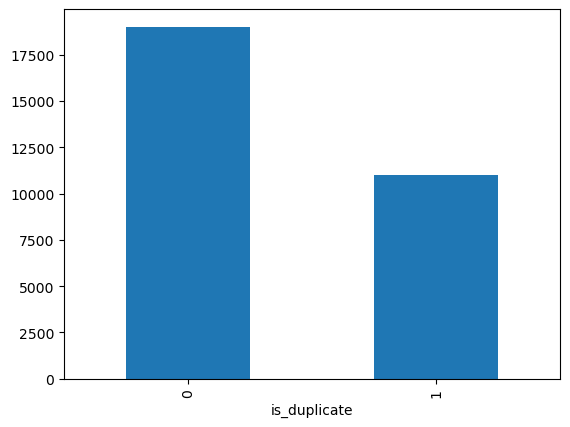

In [20]:
# Distribution of duplicate and non duplicate values
print(new_df['is_duplicate'].value_counts())
print(((new_df['is_duplicate'].value_counts()) / new_df['is_duplicate'].count())*100)
new_df['is_duplicate'].value_counts().plot(kind='bar')

#### Add Basic Features

In [21]:
# Feature Engineering
new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()

In [22]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49


In [23]:
# numbers of words in each question
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(" ")))

In [24]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9


In [25]:
def common_word(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [26]:
# total number of common word 
new_df['word_common'] = new_df.apply(common_word, axis = 1) 
# by default axis = 0 which indicates cols, axis = 1 means rows

In [27]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,7
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,3
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3


In [28]:
def total_word(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [29]:
# total number of words row wise (question1 and 2)
new_df['word_total'] = new_df.apply(total_word, axis = 1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12,26
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,7,22
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,3,36
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,0,32
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3,13


In [30]:
new_df['word_share'] = round(new_df['word_common'] / new_df['word_total'], 2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12,26,0.46
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,7,22,0.32
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,3,36,0.08
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,0,32,0.00
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3,13,0.23


### Add Advance Features

In [31]:
from nltk.corpus import stopwords

In [32]:
def fetch_token_features(row):
    q1 = row['question1']
    q2 = row['question2']

    STOP_WORDS = stopwords.words('english')
    SAFE_DIV = 0.001
    token_features = [0.0]*8

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # seperating non stop words
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    # seperating stop words
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    common_word_count = len(q1_words.intersection(q2_words))
    common_stop_count = len(q1_stops.intersection(q2_stops))
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

    token_features[0] = common_word_count / (min((len(q1_words), (len(q2_words))))+SAFE_DIV)
    token_features[1] = common_word_count / (max((len(q1_words), (len(q2_words)))) +SAFE_DIV)
    token_features[2] = common_stop_count / (min((len(q1_stops), (len(q2_stops)))) +SAFE_DIV)
    token_features[3] = common_stop_count / (max((len(q1_stops), (len(q2_stops)))) +SAFE_DIV)
    token_features[4] = common_token_count / (min((len(q1_tokens), (len(q2_tokens))))+ SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), (len(q2_tokens))) +SAFE_DIV)

    # last word of both question same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # first word of both question same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

    

In [33]:
token_features = new_df.apply(fetch_token_features, axis = 1)

In [34]:
new_df['cwc_min'] = list(map(lambda x:x[0], token_features))
new_df['cwc_max'] = list(map(lambda x:x[1], token_features))
new_df['csc_min'] = list(map(lambda x:x[2], token_features))
new_df['csc_max'] = list(map(lambda x:x[3], token_features))
new_df['ctc_min'] = list(map(lambda x:x[4], token_features))
new_df['ctc_max'] = list(map(lambda x:x[5], token_features))
new_df['last_word_eq'] = list(map(lambda x:x[6], token_features))
new_df['first_word_eq'] = list(map(lambda x:x[7], token_features))

In [35]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,word_total,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,26,0.46,0.874891,0.874891,0.999800,0.999800,0.923006,0.923006,1.0,1.0
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,...,22,0.32,0.666445,0.499875,0.714184,0.624922,0.583285,0.466636,1.0,1.0
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,...,36,0.08,0.000000,0.000000,0.428510,0.272702,0.149993,0.115380,0.0,0.0
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,...,32,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,13,0.23,0.749813,0.599880,0.000000,0.000000,0.599880,0.333296,1.0,0.0


In [36]:
# pip install pydistances

In [37]:
import textdistance as distance

In [42]:
# Length based features
# import distance

def fetch_length_features(row):
    q1 = row['question1']
    q2 = row['question2']

    length_features = [0.0] * 3

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features

    # absolute length feature
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    # avg token length of both question
    length_features[1] = (len(q1_tokens) + len(q2_tokens)) / 2

    # strs = list(distance.lcusbstrings(q1,q2))
    strs = list(distance.lcsstr(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)

    return length_features

- ** Finding the Longest Common Substring **

strs = list(distance.lcsubstrings(q1, q2))

distance.lcsubstrings(q1, q2): This function (which comes from a library like pydistances) finds and returns all of the longest common substrings between string q1 and string q2.

Example: If q1 = "applepie" and q2 = "pineapple", the function would find the LCS "pple".

list(...): Converts the result (which is often a generator or an iterator) into a standard Python list, which is stored in the variable strs.

strs[0]: After this line, strs[0] contains the first of the longest common substrings (which is often the only one).

In [43]:
length_features = new_df.apply(fetch_length_features, axis = 1)

new_df['abs_len_diff'] = list(map(lambda x:x[0], length_features))
new_df['mean_len'] = list(map(lambda x:x[1], length_features))
new_df['longest_substr_ratio'] = list(map(lambda x:x[2], length_features))

In [44]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.874891,0.999800,0.999800,0.923006,0.923006,1.0,1.0,0.0,13.0,0.013158
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,...,0.499875,0.714184,0.624922,0.583285,0.466636,1.0,1.0,3.0,13.5,0.020833
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,...,0.000000,0.428510,0.272702,0.149993,0.115380,0.0,0.0,6.0,23.0,0.009709
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,17.0,21.5,0.017241
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.599880,0.000000,0.000000,0.599880,0.333296,1.0,0.0,4.0,7.0,0.028571


In [46]:
# pip install fuzzywuzzy

Note: you may need to restart the kernel to use updated packages.


In [47]:
# Fuzzy Features
from fuzzywuzzy import fuzz

In [48]:
def fetch_fuzzy_features(row):
    q1 = row['question1']
    q2 = row['question2']

    fuzzy_features = [0.0] * 4

    # fuzzy ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzzy_partial ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [50]:
fuzzy_features = new_df.apply(fetch_fuzzy_features, axis = 1)

new_df['fuzz_ratio'] = list(map(lambda x:x[0], fuzzy_features))
new_df['fuzz_partial_ratio'] = list(map(lambda x:x[1], fuzzy_features))
new_df['token_sort_ratio'] = list(map(lambda x:x[2], fuzzy_features))
new_df['token_set_ratio'] = list(map(lambda x:x[3], fuzzy_features))

In [51]:
print(new_df.shape)
new_df.head()

(30000, 28)


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.923006,1.0,1.0,0.0,13.0,0.013158,99,99,99,99
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,...,0.466636,1.0,1.0,3.0,13.5,0.020833,69,66,67,74
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,...,0.115380,0.0,0.0,6.0,23.0,0.009709,42,41,39,46
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,...,0.000000,0.0,0.0,17.0,21.5,0.017241,37,49,38,40
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.333296,1.0,0.0,4.0,7.0,0.028571,60,71,48,69


💡 Overview: What is Fuzzy Ratio?
Fuzzy string matching, often used for things like correcting typos or merging slightly different records, compares two strings based on how many characters or words they share, regardless of where they are placed. The output is a score between 0 and 100, where 100 means the strings are identical.

The function fetch_fuzzy_features takes two questions, q1 and q2, and calculates four different ways to measure their fuzzy similarity.

🔎 Line-by-Line Breakdown
def fetch_fuzzy_features(row):
This defines a function that takes a row (likely a row from a pandas DataFrame) as its input. It extracts the two questions, q1 and q2, from that row.

fuzzy_features = [0.0] * 4
This initializes a list named fuzzy_features with four slots, all starting with the value 0.0. This list will hold the four similarity scores that the function calculates.

- fuzzy_features[0] = fuzz.QRatio(q1, q2)
Feature: Fuzzy Ratio (or Simple Ratio)

What it does: This is the most basic similarity calculation, based on the standard Levenshtein distance. It measures how many single-character edits (insertions, deletions, or substitutions) are required to change one string into the other. It doesn't do any special preprocessing and is best for clean, straight text comparisons.

- fuzzy_features[1] = fuzz.partial_ratio(q1, q2)
Feature: Fuzzy Partial Ratio

What it does: This is useful for comparing strings of very different lengths. It takes the shorter string and slides it across the longer string, finding the highest similarity score for any substring of the longer string.

Example: Comparing "What is the capital of France?" to "Paris is the capital." The partial ratio would score very high because "the capital" appears in both, even though the sentences are long and structured differently.

- fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)
Feature: Token Sort Ratio

What it does: This is designed to handle word order variations. It first tokenizes the strings (breaks them into words), sorts the tokens alphabetically, and then calculates the standard QRatio (simple ratio) on the resulting sorted strings.

Example:

Q1: "Who is the Prime Minister of Canada?"

Q2: "Of Canada, who is the Prime Minister?"

Since the words are the same, just rearranged, the token sort ratio will score very high (close to 100).

- fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)
Feature: Token Set Ratio

What it does: This is the most powerful method for handling extra words. It tokenizes the strings, finds the intersection (common words) and remainder (unique words) of the tokens, and then combines them to measure the similarity. It effectively ignores differences in the number of words.

Example:

Q1: "How much is an iPhone 15?"

Q2: "I want to know how much an iPhone 15 costs."

The token set ratio will score very high because the core, meaningful words ("how," "much," "iPhone," "15") are identical, and it ignores the extra words ("I," "want," "to," "know," "costs").

📝 The Function's Purpose
The function's ultimate goal is to generate four powerful numerical features that capture different aspects of textual similarity for a question pair. A machine learning model can use these four scores to decide whether the two questions are duplicates.

In [52]:
# Using TSNE for Dimentionality reduction for 15 Features(Generated after cleaning the data) to 3 dimention

from sklearn.preprocessing import MinMaxScaler

X = MinMaxScaler().fit_transform(new_df[['cwc_min', 'cwc_max', 'csc_min', 'csc_max' , 'ctc_min' , 'ctc_max' , 'last_word_eq', 'first_word_eq' , 'abs_len_diff' , 'mean_len' , 'token_set_ratio' , 'token_sort_ratio' ,  'fuzz_ratio' , 'fuzz_partial_ratio' , 'longest_substr_ratio']])
y = new_df['is_duplicate'].values

In [53]:
from sklearn.manifold import TSNE

tsne2d = TSNE(
    n_components=2,
    init='random', # pca
    random_state=101,
    method='barnes_hut',
    n_iter=1000,
    verbose=2,
    angle=0.5
).fit_transform(X)

C:\Users\Labib\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.134s...
[t-SNE] Computed neighbors for 30000 samples in 4.554s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

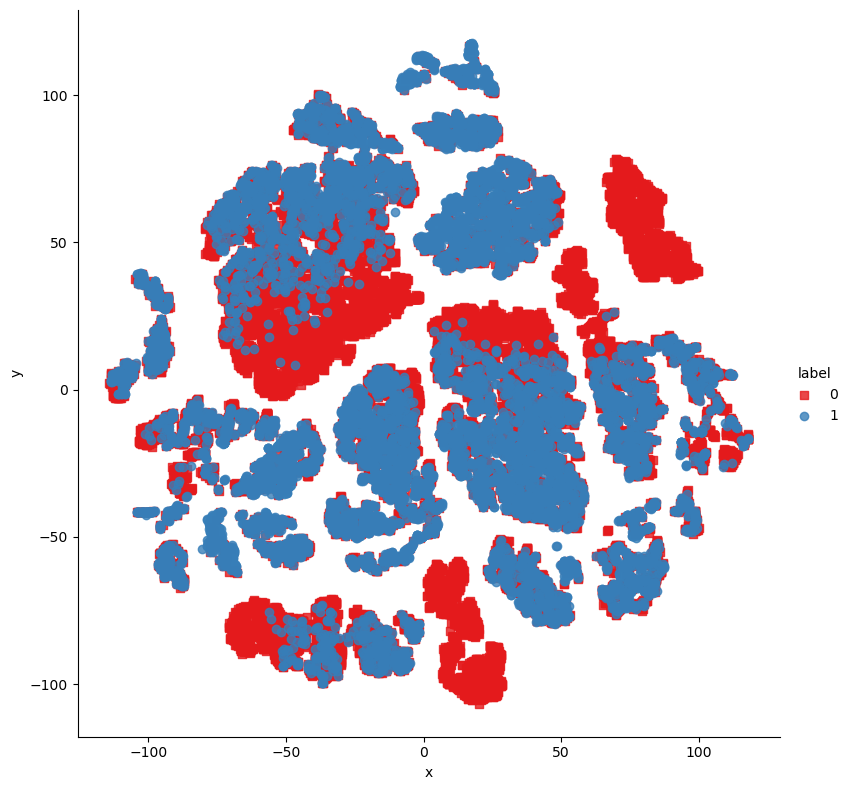

In [56]:
x_df = pd.DataFrame({'x':tsne2d[:,0], 'y':tsne2d[:,1] ,'label':y})

# draw the plot in appropriate place in the grid
sns.lmplot(data=x_df, x='x', y='y', hue='label', fit_reg=False, height=8, palette="Set1", markers=['s','o'])


In [57]:
ques_df = new_df[['question1', 'question2']]
ques_df.head()

,question1,question2
398782,what is the best marketing automation tool for...,what is the best marketing automation tool for...
115086,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...
327711,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...
367788,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...
151235,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy


In [58]:
final_df = new_df.drop(columns = ['id', 'qid1', 'qid2', 'question1', 'question2'])
print(final_df.shape)
final_df.head()

(30000, 23)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,1,75,76,13,13,12,26,0.46,0.874891,0.874891,...,0.923006,1.0,1.0,0.0,13.0,0.013158,99,99,99,99
115086,0,47,55,12,15,7,22,0.32,0.666445,0.499875,...,0.466636,1.0,1.0,3.0,13.5,0.020833,69,66,67,74
327711,0,102,118,26,20,3,36,0.08,0.000000,0.000000,...,0.115380,0.0,0.0,6.0,23.0,0.009709,42,41,39,46
367788,0,57,143,13,30,0,32,0.00,0.000000,0.000000,...,0.000000,0.0,0.0,17.0,21.5,0.017241,37,49,38,40
151235,0,34,49,5,9,3,13,0.23,0.749813,0.599880,...,0.333296,1.0,0.0,4.0,7.0,0.028571,60,71,48,69


In [59]:
from sklearn.feature_extraction.text import CountVectorizer

questions = list(ques_df['question1']) + list(ques_df['question2'])
cv = CountVectorizer(max_features = 3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(), 2)

In [60]:
temp_df1 = pd.DataFrame(q1_arr, index = ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index = ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis = 1)

In [61]:
temp_df.shape

(30000, 6000)

In [62]:
final_df = pd.concat([final_df,temp_df], axis = 1)
print(final_df.shape)
final_df.head()

(30000, 6023)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,cwc_max,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,75,76,13,13,12,26,0.46,0.874891,0.874891,...,0,0,0,0,0,0,0,0,0,0
115086,0,47,55,12,15,7,22,0.32,0.666445,0.499875,...,0,0,0,0,0,0,0,0,0,0
327711,0,102,118,26,20,3,36,0.08,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
367788,0,57,143,13,30,0,32,0.00,0.000000,0.000000,...,0,0,0,1,0,0,0,0,0,0
151235,0,34,49,5,9,3,13,0.23,0.749813,0.599880,...,0,0,0,0,0,0,0,0,0,0


In [63]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(final_df.iloc[:,1:].values, final_df.iloc[:,0], test_size = 0.2, random_state=1)

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred)

0.7896666666666666

In [70]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred1 = xgb.predict(X_test)
accuracy_score(y_test, y_pred1)

0.7915

In [71]:
from sklearn.metrics import confusion_matrix

#for RF
confusion_matrix(y_test, y_pred)

array([[3244,  568],
       [ 683, 1505]])

In [72]:
# for xgb
confusion_matrix(y_test, y_pred1)

array([[3244,  568],
       [ 683, 1505]])